# 01 — Variable-only events: Strict vs Variable 1nt

**Question:** When we relax the splice site boundary by 1nt, which splicing events does SUPPA newly detect that strict mode missed?

**Why this matters:** Strict mode requires exact splice site matches; variable 1nt tolerates a 1 nucleotide shift. The relaxation reveals more events. We need to know exactly which events are new, because the next step (notebook 03) compares PSI values event-by-event between the two modes, and that only works if we can match the same event across both.

**Data:** IOE catalogues from generateEvents (no expression yet). Event types: A3, A5, RI.

**The obstacle:** the two modes label the same event with different coordinate formats, so we cannot compare IDs directly until we translate one into the other.

| Event | Strict ID format | Variable ID format |
|-------|-----------------|-------------------|
| RI | `gene;RI:chr:s1:e1-s2:e2:strand` | `gene;RI:chr:e1-s2:strand` |
| A3 | `gene;A3:chr:e1-s2:e1-s3:strand` | `gene;A3:chr:s2:s3:strand` |
| A5 | `gene;A5:chr:e2-s3:e1-s3:strand` | `gene;A5:chr:e2:e1:strand` |

In [31]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# --- Paths ---
IOE_STRICT = "/Users/gricey/Desktop/Internship/data/output_strict/events"
IOE_VAR1   = "/Users/gricey/Desktop/Internship/data/output_variable_1nt/events"
OUTPUT_DIR = "/Users/gricey/Desktop/Internship/data/ioe_diff"
os.makedirs(OUTPUT_DIR, exist_ok=True)

EVENTS       = ["A3", "A5", "RI"]
SUFFIX_STRICT = "strict"
SUFFIX_VAR1   = "variable_1"

# --- Table helpers ---

def style_table(df, caption=""):
    styled = df.style\
        .set_properties(**{
            "font-size": "12px",
            "font-weight": "bold",
            "border": "1px solid #ddd",
            "padding": "6px 12px",
            "text-align": "center"
        })\
        .set_table_styles([
            {"selector": "th", "props": [
                ("background-color", "#2196F3"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("padding", "6px 12px"),
                ("text-align", "center")
            ]},
            {"selector": "tr:nth-child(even)", "props": [
                ("background-color", "#f2f2f2")
            ]},
        ])\
        .hide(axis="index")
    if caption:
        styled = styled.set_caption(caption)
    return styled


def export_table_png(df, filepath, title="", figsize=None):
    if figsize is None:
        figsize = (len(df.columns) * 2.2, len(df) * 0.6 + 0.8)
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.6)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor("#2196F3")
            cell.set_text_props(color="white", fontweight="bold")
        elif row % 2 == 0:
            cell.set_facecolor("#f2f2f2")
        else:
            cell.set_facecolor("white")
        cell.set_edgecolor("#dddddd")
    if title:
        ax.set_title(title, fontsize=12, pad=10)
    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved -> {filepath}")

print("Setup done!")

Setup done!


## The translation step: reformat strict IDs into variable format

**Why:** variable mode drops some coordinates that strict keeps. To match an event across both modes, we rewrite each strict ID keeping only the coordinates variable uses.

**How (strand matters):** A3 and A5 relax a biologically defined boundary (the 3' or 5' splice site). On the minus strand that boundary sits on the opposite genomic side, so the coordinates we keep flip:
- **RI**: keep the inner `e1-s2` pair (same for both strands)
- **A3**: plus strand keep right sides `s2:s3`, minus strand keep left sides `e2:e1`
- **A5**: plus strand keep left sides `e2:e1`, minus strand keep right sides `s2:s3`

The sanity check proves the translation is correct on known examples before we trust it on thousands of rows. If it fails, everything downstream is wrong.

In [32]:
def reformat_strict_event_id(event_id, event_type):
    try:
        gene_part, rest = event_id.split(";")
        tokens = rest.split(":")
        etype  = tokens[0]
        chrom  = tokens[1]
        strand = tokens[-1]
        coords = tokens[2:-1]

        if event_type == "RI":
            # same for both strands: keep the hyphenated inner pair e1-s2
            inner = [c for c in coords if "-" in c]
            if len(inner) != 1:
                return None
            return f"{gene_part};{etype}:{chrom}:{inner[0]}:{strand}"

        elif event_type == "A3":
            if len(coords) != 2:
                return None
            if strand == "+":
                # plus: e1-s2 | e1-s3 -> keep right sides: s2:s3
                c1 = coords[0].split("-")[1]
                c2 = coords[1].split("-")[1]
            else:
                # minus: e2-s3 | e1-s3 -> keep left sides: e2:e1
                c1 = coords[0].split("-")[0]
                c2 = coords[1].split("-")[0]
            return f"{gene_part};{etype}:{chrom}:{c1}:{c2}:{strand}"

        elif event_type == "A5":
            if len(coords) != 2:
                return None
            if strand == "+":
                # plus: e2-s3 | e1-s3 -> keep left sides: e2:e1
                c1 = coords[0].split("-")[0]
                c2 = coords[1].split("-")[0]
            else:
                # minus: e1-s2 | e1-s3 -> keep right sides: s2:s3
                c1 = coords[0].split("-")[1]
                c2 = coords[1].split("-")[1]
            return f"{gene_part};{etype}:{chrom}:{c1}:{c2}:{strand}"

    except Exception:
        return None


# Sanity checks using real examples from terminal
tests = [
    ("RI", "ENSMUSG00000019082;RI:7:141011934:141012052-141012527:141012666:-",
            "ENSMUSG00000019082;RI:7:141012052-141012527:-"),
    ("A3", "ENSMUSG00000057363;A3:1:43829804-43836405:43829710-43836405:-",
            "ENSMUSG00000057363;A3:1:43829804:43829710:-"),
    ("A5", "ENSMUSG00000000088;A5:9:57437645-57438952:57436355-57438952:+",
            "ENSMUSG00000000088;A5:9:57437645:57436355:+"),
]

print("Sanity checks:")
all_ok = True
for etype, strict_id, expected in tests:
    result = reformat_strict_event_id(strict_id, etype)
    ok = result == expected
    if not ok:
        all_ok = False
    print(f"  {etype}: {'OK' if ok else f'MISMATCH -> got {result}'}")

print()
print("All sanity checks passed!" if all_ok else "Some checks failed, review reformatting logic.")

Sanity checks:
  RI: OK
  A3: OK
  A5: OK

All sanity checks passed!


## Step 1 — Load the catalogues

Read both IOE files per event type. Each row is one event. The printed counts show the raw gap between modes, which is what we are about to explain.

In [33]:
ioe_data = {}

for event in EVENTS:
    ioe_data[event] = {
        "strict": pd.read_csv(f"{IOE_STRICT}/events_{event}_{SUFFIX_STRICT}.ioe", sep="\t"),
        "var1":   pd.read_csv(f"{IOE_VAR1}/events_{event}_{SUFFIX_VAR1}.ioe",   sep="\t"),
    }
    s = len(ioe_data[event]["strict"])
    v = len(ioe_data[event]["var1"])
    print(f"{event}  |  n_e_strict = {s:>6}  |  n_e_var1 = {v:>6}  |  difference = {v-s:>6}")

A3  |  n_e_strict =  11163  |  n_e_var1 =  22931  |  difference =  11768
A5  |  n_e_strict =   9629  |  n_e_var1 =  19455  |  difference =   9826
RI  |  n_e_strict =   5315  |  n_e_var1 =  17336  |  difference =  12021


## Step 2 — Classify every variable event

Reformat all strict IDs, then check each variable event: does its ID appear in the reformatted strict set?

- **n_e_shared** — yes, detected in both modes (these can be compared in notebook 03)
- **n_e_var_only** — no, only in variable, known Ensembl gene
- **n_e_var_novel** — no, only in variable, no Ensembl ID (coordinate-based)

Every variable event lands in exactly one bucket, so the three always sum to n_e_var1.

**Why event level:** PSI is a property of a single event, so ΔPSI in notebook 03 needs event-by-event pairing. Gene level cannot provide that.

In [34]:
populations = {}  # stores event ID sets and dataframes per event type
rows = []

for event in EVENTS:
    strict_df = ioe_data[event]["strict"].copy()
    var1_df   = ioe_data[event]["var1"]

    # All variable event IDs
    var1_ids = set(var1_df["event_id"])

    # Reformat strict IDs to variable format
    strict_df["event_id_var_fmt"] = strict_df["event_id"].apply(
        lambda x: reformat_strict_event_id(x, event)
    )
    n_reformatted = strict_df["event_id_var_fmt"].notna().sum()
    print(f"{event}: {n_reformatted}/{len(strict_df)} strict events reformatted successfully")

    strict_var_fmt = set(strict_df["event_id_var_fmt"].dropna())

    # Classify variable events
    shared      = var1_ids & strict_var_fmt
    var_only    = var1_ids - strict_var_fmt
    var_only_e  = {e for e in var_only if e.split(";")[0].startswith("ENSMUSG")}
    var_only_n  = {e for e in var_only if not e.split(";")[0].startswith("ENSMUSG")}

    populations[event] = {
        "shared":          shared,
        "var_only":        var_only_e,
        "var_novel":       var_only_n,
        "strict_var_fmt":  strict_var_fmt,
        "strict_df":       strict_df,
        "var1_df":         var1_df,
    }

    rows.append({
        "Event":           event,
        "n_e_strict":      len(strict_df),
        "n_e_var1":        len(var1_df),
        "n_e_shared":      len(shared),
        "n_e_var_only":    len(var_only_e),
        "n_e_var_novel":   len(var_only_n),
    })

print()
df_pop = pd.DataFrame(rows)
display(style_table(df_pop, "Table — Event-level comparison: Strict vs Variable 1nt"))
export_table_png(
    df_pop,
    "../../figures/plots/table_event_populations.png",
    title="Event-level comparison: Strict vs Variable 1nt",
    figsize=(14, 3)
)

A3: 11163/11163 strict events reformatted successfully
A5: 9629/9629 strict events reformatted successfully
RI: 5315/5315 strict events reformatted successfully



Event,n_e_strict,n_e_var1,n_e_shared,n_e_var_only,n_e_var_novel
A3,11163,22931,10750,12181,0
A5,9629,19455,9251,10204,0
RI,5315,17336,5073,12262,1


Saved -> ../../figures/plots/table_event_populations.png


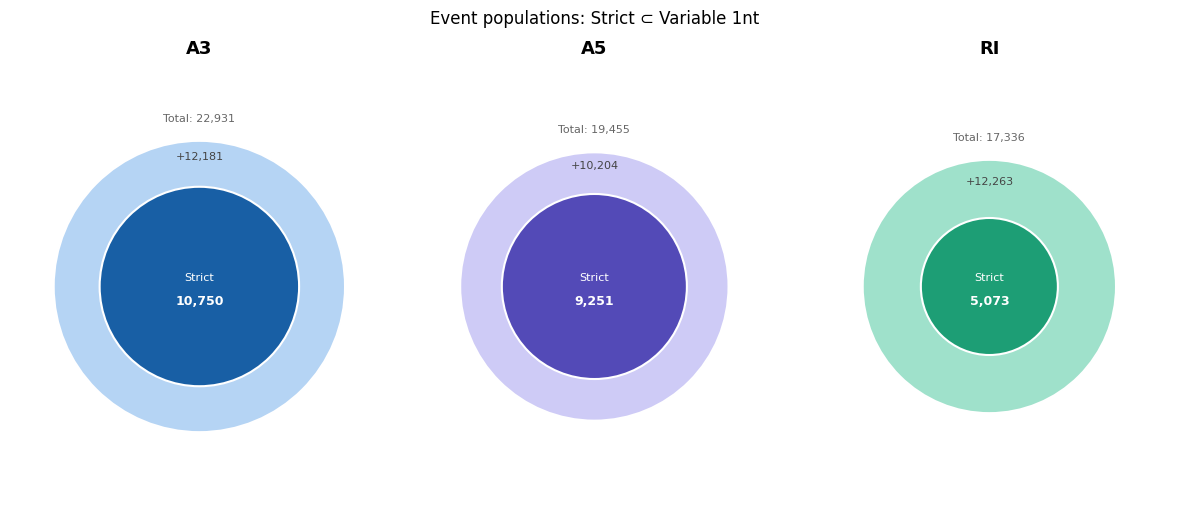

Saved!


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

colors = {
    "RI": {"outer": "#9FE1CB", "inner": "#1D9E75"},
    "A3": {"outer": "#B5D4F4", "inner": "#185FA5"},
    "A5": {"outer": "#CECBF6", "inner": "#534AB7"},
}

max_var1 = max(len(populations[e]["var1_df"]) for e in EVENTS)

for i, event in enumerate(EVENTS):
    pop = populations[event]
    n_strict_fmt = len(pop["strict_var_fmt"])
    n_var1       = len(pop["var1_df"])
    n_gained     = len(pop["var_only"]) + len(pop["var_novel"])

    ax = axes[i]
    ax.set_aspect("equal")
    ax.axis("off")

    r_outer = np.sqrt(n_var1 / max_var1)
    r_inner = np.sqrt(n_strict_fmt / max_var1)

    outer = plt.Circle((0, 0), r_outer, color=colors[event]["outer"],
                        ec="white", linewidth=1.5)
    inner = plt.Circle((0, 0), r_inner, color=colors[event]["inner"],
                        ec="white", linewidth=1.5)

    ax.add_patch(outer)
    ax.add_patch(inner)
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.5, 1.5)

    # inner label: "Strict" + count
    ax.text(0, 0.06, "Strict", ha="center", va="center",
            fontsize=8, color="white")
    ax.text(0, -0.1, f"{n_strict_fmt:,}", ha="center", va="center",
            fontsize=9, fontweight="bold", color="white")

    # outer ring label: variable-only count in the ring area
    ring_mid = (r_inner + r_outer) / 2
    ax.text(0, ring_mid + 0.05, f"+{n_gained:,}", ha="center", va="center",
            fontsize=8, color="#444444")

    # total label above circle
    ax.text(0, r_outer + 0.15, f"Total: {n_var1:,}", ha="center", va="center",
            fontsize=8, color="#666666")

    ax.set_title(event, fontsize=13, fontweight="bold", pad=10)

plt.suptitle("Event populations: Strict ⊂ Variable 1nt",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../../figures/plots/venn_concentric_event_populations.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

In [36]:
# Table 2 — Coordinate reformatting resolution
# Shows the "flow": strict -> strict_fmt (after dedup) -> variable

rows_flow = []

for event in EVENTS:
    pop = populations[event]
    strict_df = pop["strict_df"]
    var1_df   = pop["var1_df"]

    n_strict     = len(strict_df)
    n_strict_fmt = len(pop["strict_var_fmt"])   # unique reformatted strict IDs
    n_lost       = n_strict - n_strict_fmt
    n_var1       = len(var1_df)
    n_gained     = n_var1 - n_strict_fmt        # var_only + var_novel

    rows_flow.append({
        "Event":            event,
        "strict":           n_strict,
        "strict_fmt":       n_strict_fmt,
        "lost to dedup":    n_lost,
        "var1":             n_var1,
        "gained in var":    n_gained,
    })

df_flow = pd.DataFrame(rows_flow)
display(style_table(df_flow, "Table — Strict to strict_fmt to Variable 1nt"))
export_table_png(
    df_flow,
    "../../figures/plots/table_event_flow.png",
    title="Strict to strict_fmt to Variable 1nt",
    figsize=(14, 3)
)

Event,strict,strict_fmt,lost to dedup,var1,gained in var
A3,11163,10750,413,22931,12181
A5,9629,9251,378,19455,10204
RI,5315,5073,242,17336,12263


Saved -> ../../figures/plots/table_event_flow.png


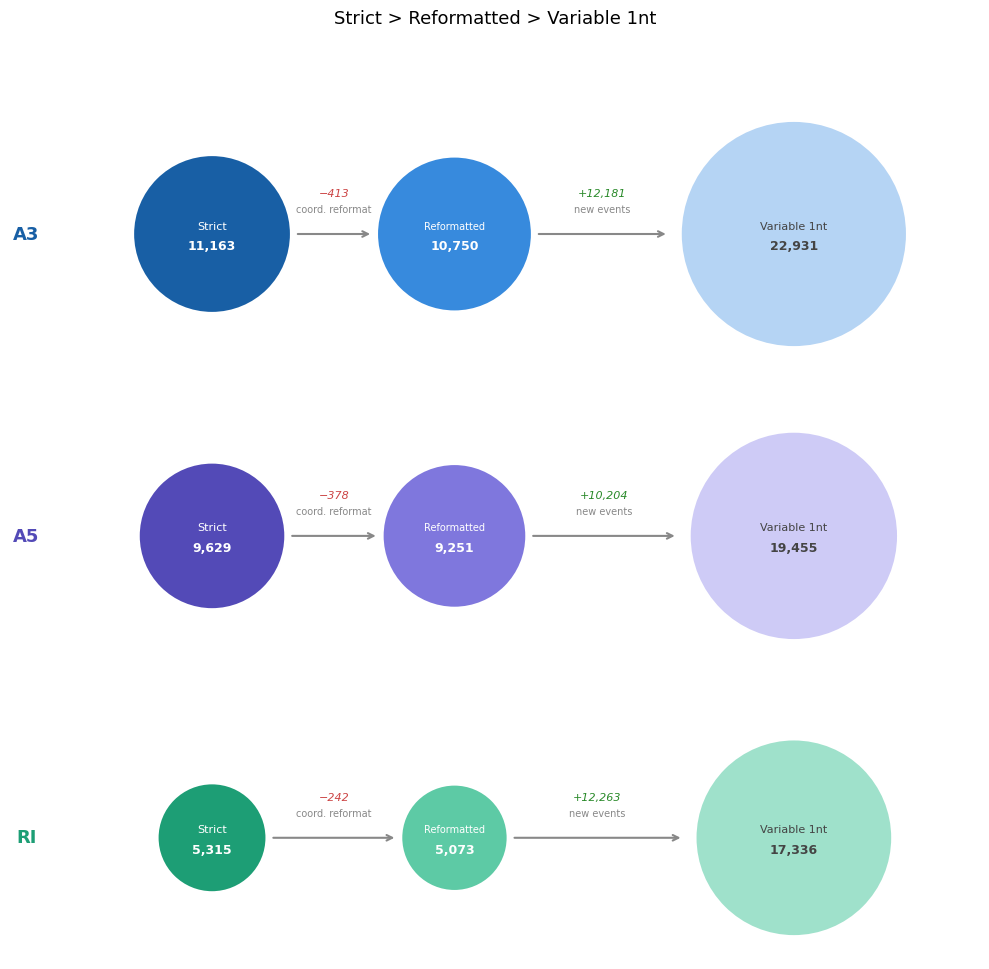

Saved!


In [37]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

colors = {
    "RI": {"strict": "#1D9E75", "fmt": "#5DCAA5", "var1": "#9FE1CB"},
    "A3": {"strict": "#185FA5", "fmt": "#378ADD", "var1": "#B5D4F4"},
    "A5": {"strict": "#534AB7", "fmt": "#7F77DD", "var1": "#CECBF6"},
}

max_n = max(len(populations[e]["var1_df"]) for e in EVENTS)

for i, event in enumerate(EVENTS):
    pop = populations[event]
    n_strict     = len(pop["strict_df"])
    n_strict_fmt = len(pop["strict_var_fmt"])
    n_var1       = len(pop["var1_df"])
    n_lost       = n_strict - n_strict_fmt
    n_gained     = len(pop["var_only"]) + len(pop["var_novel"])

    ax = axes[i]
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-0.5, 11.5)
    ax.set_ylim(-1.5, 1.5)

    r_strict     = np.sqrt(n_strict / max_n)
    r_strict_fmt = np.sqrt(n_strict_fmt / max_n)
    r_var1       = np.sqrt(n_var1 / max_n)

    scale = 1.4
    positions = [2.0, 5.0, 9.2]

    c1 = plt.Circle((positions[0], 0), r_strict * scale,
                     color=colors[event]["strict"], ec="white", linewidth=1.5)
    c2 = plt.Circle((positions[1], 0), r_strict_fmt * scale,
                     color=colors[event]["fmt"], ec="white", linewidth=1.5)
    c3 = plt.Circle((positions[2], 0), r_var1 * scale,
                     color=colors[event]["var1"], ec="white", linewidth=1.5)

    ax.add_patch(c1)
    ax.add_patch(c2)
    ax.add_patch(c3)

    # first arrow: strict -> reformatted
    ax.annotate("", xy=(positions[1] - r_strict_fmt * scale - 0.05, 0),
                xytext=(positions[0] + r_strict * scale + 0.05, 0),
                arrowprops=dict(arrowstyle="->", color="#888888", lw=1.5))

    # second arrow: reformatted -> variable
    ax.annotate("", xy=(positions[2] - r_var1 * scale - 0.15, 0),
                xytext=(positions[1] + r_strict_fmt * scale + 0.05, 0),
                arrowprops=dict(arrowstyle="->", color="#888888", lw=1.5))

    # circle labels
    ax.text(positions[0], 0.1, "Strict", ha="center", va="center",
            fontsize=8, color="white")
    ax.text(positions[0], -0.15, f"{n_strict:,}", ha="center", va="center",
            fontsize=9, fontweight="bold", color="white")

    ax.text(positions[1], 0.1, "Reformatted", ha="center", va="center",
            fontsize=7, color="white")
    ax.text(positions[1], -0.15, f"{n_strict_fmt:,}", ha="center", va="center",
            fontsize=9, fontweight="bold", color="white")

    ax.text(positions[2], 0.1, "Variable 1nt", ha="center", va="center",
            fontsize=8, color="#444444")
    ax.text(positions[2], -0.15, f"{n_var1:,}", ha="center", va="center",
            fontsize=9, fontweight="bold", color="#444444")

    # first arrow annotation (centered between actual arrow endpoints)
    arrow1_start = positions[0] + r_strict * scale + 0.05
    arrow1_end   = positions[1] - r_strict_fmt * scale - 0.05
    arrow1_mid   = (arrow1_start + arrow1_end) / 2
    ax.text(arrow1_mid, 0.5, f"−{n_lost:,}", ha="center", va="center",
            fontsize=8, color="#cc4444", fontstyle="italic")
    ax.text(arrow1_mid, 0.3, "coord. reformat", ha="center", va="center",
            fontsize=7, color="#888888")

    # second arrow annotation (centered between actual arrow endpoints)
    arrow2_start = positions[1] + r_strict_fmt * scale + 0.05
    arrow2_end   = positions[2] - r_var1 * scale - 0.15
    arrow2_mid   = (arrow2_start + arrow2_end) / 2
    ax.text(arrow2_mid, 0.5, f"+{n_gained:,}", ha="center", va="center",
            fontsize=8, color="#2a8a2a", fontstyle="italic")
    ax.text(arrow2_mid, 0.3, "new events", ha="center", va="center",
            fontsize=7, color="#888888")

    # event type label on the left
    ax.text(-0.3, 0, event, ha="center", va="center",
            fontsize=13, fontweight="bold",
            color=colors[event]["strict"])

plt.suptitle("Strict > Reformatted > Variable 1nt", fontsize=13, y=1.01)
plt.tight_layout(h_pad=0.1) # reduce vertical spacing between subplots
plt.savefig("../../figures/plots/flow_event_populations_rows.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

## Gene-level view: which genes are new in variable?

This answers the original biological question separately, at gene level (`n_g_`): which genes had zero events in strict but appear in variable? These are genes the strict boundary was completely blind to. This is the view used earlier to pick IGV candidate genes.

In [38]:
# --- Gene-level view: which genes are newly detected in variable? ---
# This answers the original question: relaxing the boundary by 1nt reveals
# events in genes that strict detected zero events for.

rows_gene = []

for event in EVENTS:
    strict_df = ioe_data[event]["strict"]
    var1_df   = ioe_data[event]["var1"]

    # Gene sets (ENSMUSG only)
    strict_genes = set(g for g in strict_df["gene_id"] if str(g).startswith("ENSMUSG"))
    var1_genes   = set(g for g in var1_df["gene_id"]   if str(g).startswith("ENSMUSG"))

    # Genes only in variable (never detected in strict)
    new_genes = var1_genes - strict_genes

    rows_gene.append({
        "Event":          event,
        "n_g_strict":     len(strict_genes),
        "n_g_var1":       len(var1_genes),
        "n_g_new (v-s)":        len(new_genes),
    })

df_gene = pd.DataFrame(rows_gene)
display(style_table(df_gene, "Gene-level: genes newly detected in Variable 1nt"))
export_table_png(
    df_gene,
    "../../figures/plots/table_gene_new.png",
    title="Genes newly detected in Variable 1nt",
    figsize=(11, 3)
)

Event,n_g_strict,n_g_var1,n_g_new (v-s)
A3,6684,10107,3423
A5,5905,9002,3097
RI,3163,7567,4404


Saved -> ../../figures/plots/table_gene_new.png


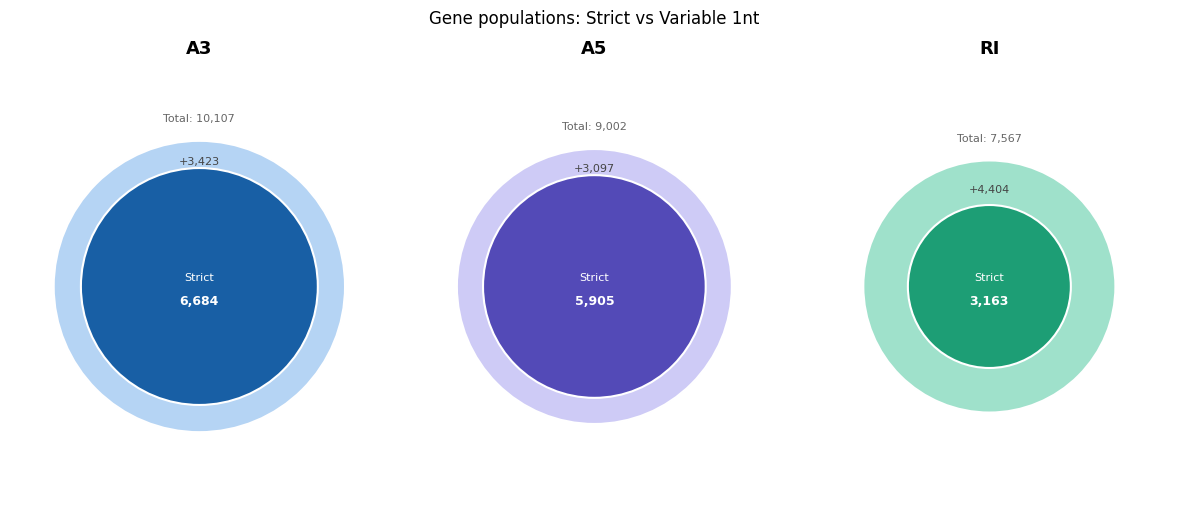

Saved!


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

colors = {
    "RI": {"outer": "#9FE1CB", "inner": "#1D9E75"},
    "A3": {"outer": "#B5D4F4", "inner": "#185FA5"},
    "A5": {"outer": "#CECBF6", "inner": "#534AB7"},
}

max_g = df_gene["n_g_var1"].max()

for i, row in df_gene.iterrows():
    event        = row["Event"]
    n_g_strict   = row["n_g_strict"]
    n_g_var1     = row["n_g_var1"]
    n_g_new      = row["n_g_new (v-s)"]

    ax = axes[i]
    ax.set_aspect("equal")
    ax.axis("off")

    r_outer = np.sqrt(n_g_var1 / max_g)
    r_inner = np.sqrt(n_g_strict / max_g)

    outer = plt.Circle((0, 0), r_outer, color=colors[event]["outer"],
                        ec="white", linewidth=1.5)
    inner = plt.Circle((0, 0), r_inner, color=colors[event]["inner"],
                        ec="white", linewidth=1.5)

    ax.add_patch(outer)
    ax.add_patch(inner)
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.5, 1.5)

    ax.text(0, 0.06, "Strict", ha="center", va="center",
            fontsize=8, color="white")
    ax.text(0, -0.1, f"{n_g_strict:,}", ha="center", va="center",
            fontsize=9, fontweight="bold", color="white")

    ring_mid = (r_inner + r_outer) / 2
    ax.text(0, ring_mid - 0.05, f"+{n_g_new:,}", ha="center", va="center",
            fontsize=8, color="#444444")

    ax.text(0, r_outer + 0.15, f"Total: {n_g_var1:,}", ha="center", va="center",
            fontsize=8, color="#666666")

    ax.set_title(event, fontsize=13, fontweight="bold", pad=10)

plt.suptitle("Gene populations: Strict vs Variable 1nt", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../../figures/plots/venn_concentric_gene_populations.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

## Step 3 — Export variable-only events

Save the variable-only events to IOE files and gene lists. These are the concrete deliverables: the material strict missed, ready for IGV and for the PSI comparison.

In [39]:
for event in EVENTS:
    pop     = populations[event]
    var1_df = pop["var1_df"]

    # All variable-only events (ENSMUSG + novel)
    var_only_all = pop["var_only"] | pop["var_novel"]

    # Filter variable IOE to variable-only events
    ioe_unique = var1_df[var1_df["event_id"].isin(var_only_all)]

    # Unique ENSMUSG gene IDs
    unique_genes = sorted(set(
        e.split(";")[0] for e in pop["var_only"]
    ))

    # Save files
    ioe_unique.to_csv(f"{OUTPUT_DIR}/{event}_var1_unique.ioe", sep="\t", index=False)
    with open(f"{OUTPUT_DIR}/{event}_var1_unique_genes.txt", "w") as f:
        for gene in unique_genes:
            f.write(gene + "\n")

    print(f"{event}:")
    print(f"  n_e_var_only = {len(pop['var_only'])} events ({len(unique_genes)} unique genes)")
    print(f"  n_e_var_novel = {len(pop['var_novel'])} events (no Ensembl ID)")
    print()

A3:
  n_e_var_only = 12181 events (6195 unique genes)
  n_e_var_novel = 0 events (no Ensembl ID)

A5:
  n_e_var_only = 10204 events (5312 unique genes)
  n_e_var_novel = 0 events (no Ensembl ID)

RI:
  n_e_var_only = 12262 events (6045 unique genes)
  n_e_var_novel = 1 events (no Ensembl ID)



## Step 4 — Superset check (validation)

If the translation is correct, every strict event must be found in variable (strict is a subset of variable). So "strict events missing from variable" must be zero for all event types. This is the proof that the matching is good, the result we show Khushi to validate the method.

In [40]:
rows_check = []

for event in EVENTS:
    pop    = populations[event]
    var1_ids           = set(pop["var1_df"]["event_id"])
    strict_var_fmt     = pop["strict_var_fmt"]
    n_strict_missing   = len(strict_var_fmt - var1_ids)
    n_total_accounted  = len(pop["shared"]) + len(pop["var_only"]) + len(pop["var_novel"])
    n_var_total        = len(pop["var1_df"])

    rows_check.append({
        "Event":                    event,
        "n_e_var1 (total)": n_var_total,
        "n_e_shared + var_only + novel": n_total_accounted,
        "accounting OK?": "yes" if n_total_accounted == n_var_total else "MISMATCH",
        "strict events missing from var": n_strict_missing,
        "superset OK?": "yes" if n_strict_missing == 0 else f"{n_strict_missing} missing!",
    })

df_check = pd.DataFrame(rows_check)
display(style_table(df_check, "Superset check: variable contains all strict events"))
export_table_png(
    df_check,
    "../../figures/plots/table_superset_check.png",
    title="Superset check: variable contains all strict events",
    figsize=(18, 3)
)

Event,n_e_var1 (total),n_e_shared + var_only + novel,accounting OK?,strict events missing from var,superset OK?
A3,22931,22931,yes,0,yes
A5,19455,19455,yes,0,yes
RI,17336,17336,yes,0,yes


Saved -> ../../figures/plots/table_superset_check.png


# pause to check barplots: gene level population distribution

In [ ]:
import pandas as pd

base = "/Users/gricey/Desktop/Internship/data/ioe_populations"

rows_q = []
for event in EVENTS:
    # Q1: genes in strict that gained events in variable
    q1_path = f"{base}/{event}_Q1_more_events.txt"
    q1 = pd.read_csv(q1_path, sep="\s+", header=None, # changed from per=\t (tab-separated) to \s+ space-separated (which handles any whitespaces (spaces or tabs)).
                     names=["gene_id", "n_strict", "n_var1", "gained"])
    n_q1 = len(q1)

    # Q2: genes invisible in strict, appear in variable
    q2_path = f"{base}/{event}_Q2_zero_to_events_genes.txt"
    with open(q2_path) as f:
        n_q2 = sum(1 for line in f if line.strip())

    # Q3: genes with novel transcript events (UUID IDs)
    q3_path = f"{base}/{event}_Q3_novel_transcripts.ioe"
    q3_df = pd.read_csv(q3_path, sep="\t")
    n_q3 = q3_df["gene_id"].nunique() if "gene_id" in q3_df.columns else len(q3_df)

    # Q4: Q1 genes that also have novel transcript events
    q1_genes = set(q1["gene_id"])
    q3_genes = set(q3_df["gene_id"]) if "gene_id" in q3_df.columns else set()
    n_q4 = len(q1_genes & q3_genes)

    rows_q.append({
        "Event": event,
        "Q1 gained":         n_q1,
        "Q2 new":            n_q2,
        "Q3 novel":          n_q3,
        "Q4 gained + novel": n_q4,
    })

df_q = pd.DataFrame(rows_q)
display(style_table(df_q, "IOE gene populations (recomputed from source files)"))
print(df_q)

Event,Q1 gained,Q2 new,Q3 novel,Q4 gained + novel
A3,2711,3423,2880,0
A5,2163,3097,2529,0
RI,1618,4405,2285,0


  Event  Q1 gained  Q2 new  Q3 novel  Q4 gained + novel
0    A3       2711    3423      2880                  0
1    A5       2163    3097      2529                  0
2    RI       1618    4405      2285                  0


In [46]:
# Check Q3 IOE file structure
q3_path = f"{base}/A3_Q3_novel_transcripts.ioe"
q3_test = pd.read_csv(q3_path, sep="\t")
print(q3_test.columns.tolist())
print(q3_test.head(3))
print(f"Total rows: {len(q3_test)}")
print(f"Unique values in first column: {q3_test.iloc[:,0].nunique()}")

['1', 'ENSMUSG00000025911', 'ENSMUSG00000025911;A3:1:9623543:9623848:+', '7d28752d-0e3c-4fa1-ab0f-d4b22c29febe', 'ENSMUST00000186467,ENSMUST00000190654,ENSMUST00000144177,9dd98dc3-f960-4b9c-ad63-8dca3bd5579f,ENSMUST00000130927,ENSMUST00000027044,7d28752d-0e3c-4fa1-ab0f-d4b22c29febe,eefe10bb-7c38-45d0-8c94-cd19494c4760-1']
   1  ENSMUSG00000025911  ENSMUSG00000025911;A3:1:9623543:9623848:+  \
0  1  ENSMUSG00000025915  ENSMUSG00000025915;A3:1:9956214:9956272:+   
1  1  ENSMUSG00000025915  ENSMUSG00000025915;A3:1:9955892:9956214:+   
2  1  ENSMUSG00000025915  ENSMUSG00000025915;A3:1:9955892:9959095:+   

                7d28752d-0e3c-4fa1-ab0f-d4b22c29febe  \
0  2eedce1a-2112-43d3-9913-dd7c0d8757d9,ENSMUST00...   
1              ENSMUST00000188738,ENSMUST00000191338   
2                                 ENSMUST00000191338   

  ENSMUST00000186467,ENSMUST00000190654,ENSMUST00000144177,9dd98dc3-f960-4b9c-ad63-8dca3bd5579f,ENSMUST00000130927,ENSMUST00000027044,7d28752d-0e3c-4fa1-ab0f-d4b22c29

In [50]:
# fixing the Q3 and Q4 comparison
rows_q = []
for event in EVENTS:
    # Q1
    q1_path = f"{base}/{event}_Q1_more_events.txt"
    q1 = pd.read_csv(q1_path, sep="\s+", header=None,
                     names=["gene_id", "n_strict", "n_var1", "gained"])
    n_q1 = len(q1)

    # Q2
    q2_path = f"{base}/{event}_Q2_zero_to_events_genes.txt"
    with open(q2_path) as f:
        n_q2 = sum(1 for line in f if line.strip())

    # Q3: read with proper header, count unique genes
    q3_path = f"{base}/{event}_Q3_novel_transcripts.ioe"
    q3_df = pd.read_csv(q3_path, sep="\t", header=None,
                        names=["seqname", "gene_id", "event_id",
                               "alt_transcripts", "total_transcripts"])
    n_q3 = q3_df["gene_id"].nunique()

    # Q4: Q1 genes that also appear in Q3
    q1_genes = set(q1["gene_id"])
    q3_genes = set(q3_df["gene_id"])
    n_q4 = len(q1_genes & q3_genes)

    rows_q.append({
        "Event":             event,
        "Q1 gained":         n_q1,
        "Q2 new":            n_q2,
        "Q3 novel":          n_q3,
        "Q4 gained + novel": n_q4,
    })

df_q = pd.DataFrame(rows_q)
display(style_table(df_q, "IOE gene populations (recomputed from source files)"))
print(df_q)

Event,Q1 gained,Q2 new,Q3 novel,Q4 gained + novel
A3,2711,3423,1266,456
A5,2163,3097,1199,413
RI,1618,4405,1041,374


  Event  Q1 gained  Q2 new  Q3 novel  Q4 gained + novel
0    A3       2711    3423      1266                456
1    A5       2163    3097      1199                413
2    RI       1618    4405      1041                374


Harcoded numbers are good, just that Q4 = 0 for all, which is suspicious... it means no Q1 genes overlap with Q3 genes.
Debug:

In [48]:
# Check what Q1 and Q3 gene IDs look like for A3
q1_path = f"{base}/A3_Q1_more_events.txt"
q1 = pd.read_csv(q1_path, sep="\t", header=None,
                 names=["gene_id", "n_strict", "n_var1", "gained"])

q3_path = f"{base}/A3_Q3_novel_transcripts.ioe"
q3_df = pd.read_csv(q3_path, sep="\t", header=None,
                    names=["seqname", "gene_id", "event_id",
                           "alt_transcripts", "total_transcripts"])

print("Q1 gene_id sample:", list(q1["gene_id"])[:3])
print("Q3 gene_id sample:", list(q3_df["gene_id"])[:3])
print("Overlap:", len(set(q1["gene_id"]) & set(q3_df["gene_id"])))

Q1 gene_id sample: ['ENSMUSG00000053332 18 46 28', 'ENSMUSG00000022546 3 25 22', 'ENSMUSG00000108414 4 25 21']
Q3 gene_id sample: ['ENSMUSG00000025911', 'ENSMUSG00000025915', 'ENSMUSG00000025915']
Overlap: 0


Q1 is space-separated, not tab-separated!